# ae_picker — Demo: Maria Project (Filtered Signals)

Demonstrates the full `ae_picker` workflow using **filtered** AE waveforms
from borehole monitoring experiments (Maria dataset, KAUST RockGem group).

| Folder | Channels | Sampling | Window |
|---|---|---|---|
| `filtered_signals/` | auto-detected | ~7984 kHz (0.13 µs) | ±250 µs centred at t=0 |

**Workflow**  
1. Load the data  
2. Plot samples of loaded data  
3. Perform event picking — AIC, Refined STA/LTA  
4. Compare the picks  
5. Plot the picks  
6. Perform uncertainty quantification

## Setup

Install `ae_picker` from the repo root before running:
```bash
pip install -e ..
```

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))

from ae_picker import (
    read_filtered,
    aic_picker, refined_stalta_picker,
    plot_channels, pick_file,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

import ae_picker
print(f"ae_picker version: {ae_picker.__version__}")

ae_picker version: 0.1.0


## 1  Load the data

In [2]:
# ── USER CONFIGURATION ───────────────────────────────────────────────────
DATA_DIR   = Path("..")                 # folder containing filtered_signals/
OUTPUT_DIR = DATA_DIR / "picks_output"
# ─────────────────────────────────────────────────────────────────────────
OUTPUT_DIR.mkdir(exist_ok=True)

filtered_files = sorted((DATA_DIR / "filtered_signals").glob("*.txt"))
print(f"Filtered files found: {len(filtered_files)}")

Filtered files found: 5


In [3]:
# Load all files; channel count is auto-detected per file
all_data = []
for fp in filtered_files:
    meta, channels = read_filtered(fp)
    all_data.append((fp, meta, channels))

rows = []
for fp, meta, channels in all_data:
    t  = channels[0]["time"]
    dt = float(np.median(np.diff(t)))
    fs = 1.0 / dt
    rows.append({
        "file":       fp.name,
        "n_channels": len(channels),
        "fs_kHz":     round(fs / 1e3, 1),
        "dt_us":      round(dt * 1e6, 3),
        "t_start_us": round(t[0]  * 1e6, 1),
        "t_end_us":   round(t[-1] * 1e6, 1),
        "n_samples":  len(t),
    })

print(pd.DataFrame(rows).to_string(index=False))

                                         file  n_channels  fs_kHz  dt_us  t_start_us  t_end_us  n_samples
Maria_P002W_002_C66_261.930_A_0.a_262.160.txt           2  7984.5  0.125      -250.0     250.0       3999
Maria_P002W_003_C01_291.960_A_0.a_292.140.txt           2  7984.5  0.125      -250.0     250.0       3999
Maria_P002W_003_C81_339.980_A_0.a_340.040.txt           2  7984.5  0.125      -250.0     250.0       3999
Maria_P002W_004_C07_356.153_A_2.a_356.873.txt           2  7984.5  0.125      -250.0     250.0       3999
Maria_P002W_004_C39_239.300_A_0.a_239.500.txt           2  7984.5  0.125      -250.0     250.0       3999


## 2  Plot samples of loaded data

Three representative files (first, middle, last) shown in full ±250 µs window.

C:\Users\wamrieds\AppData\Local\Temp\ipykernel_34660\1205275079.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


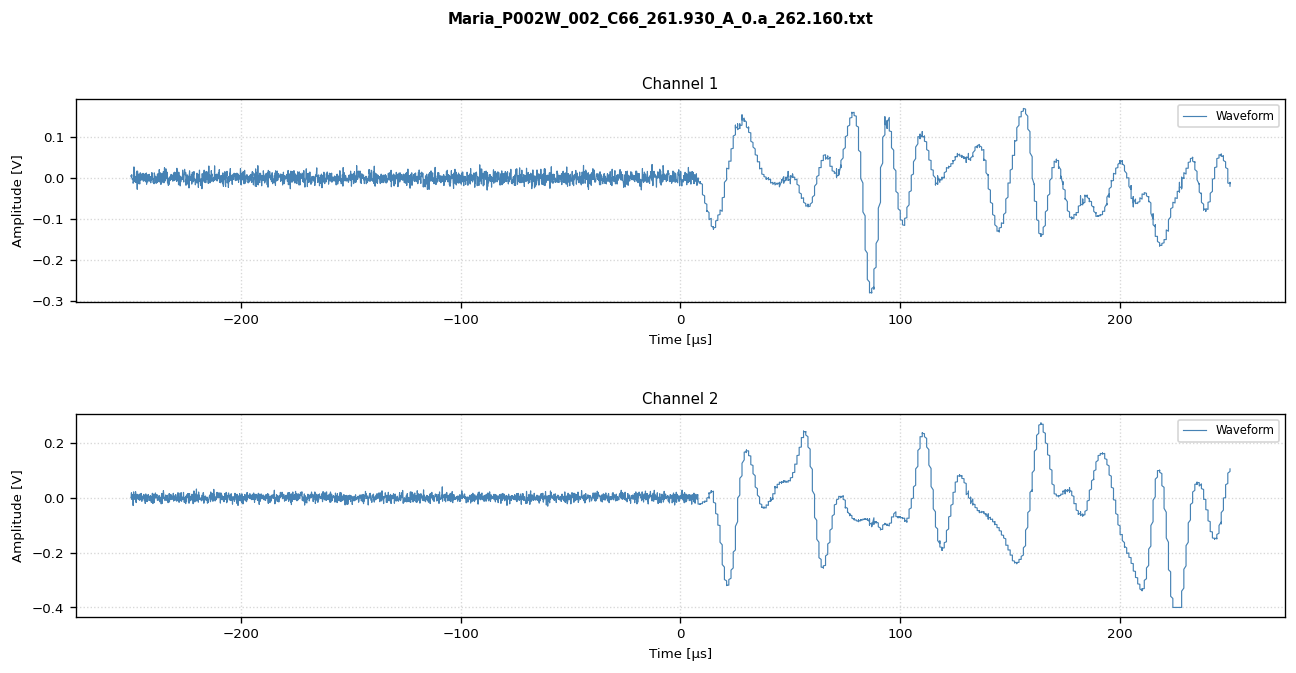

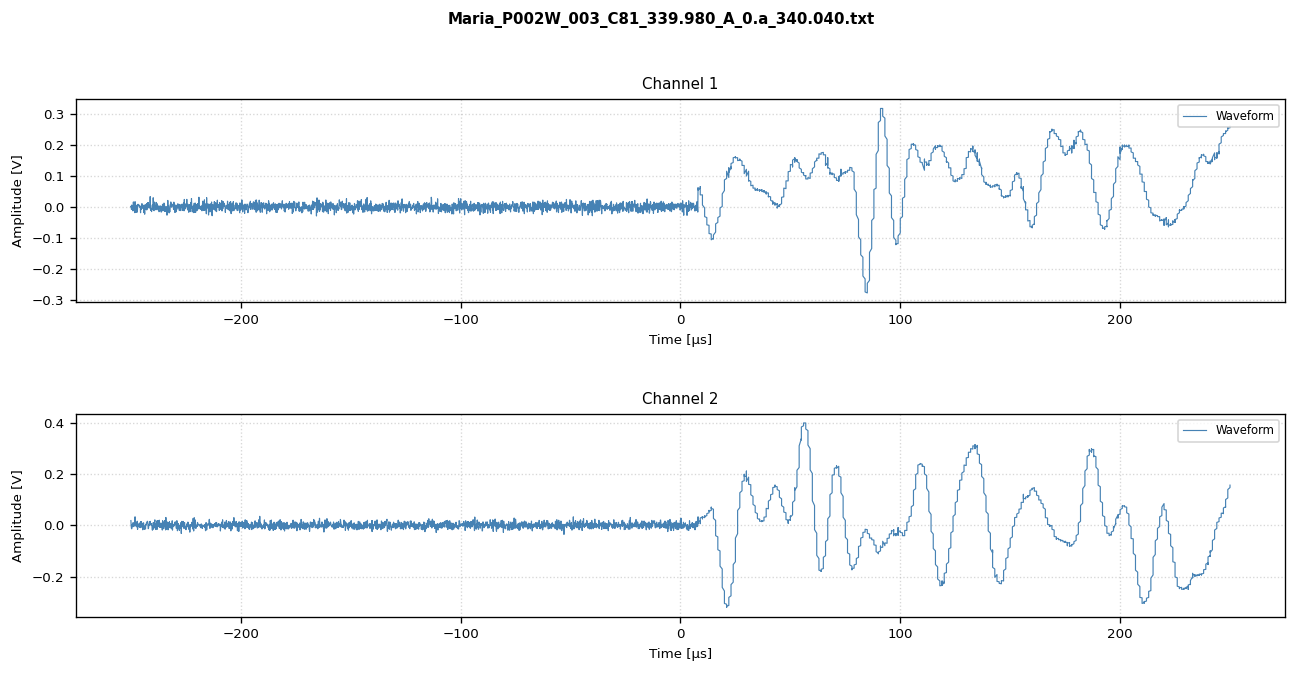

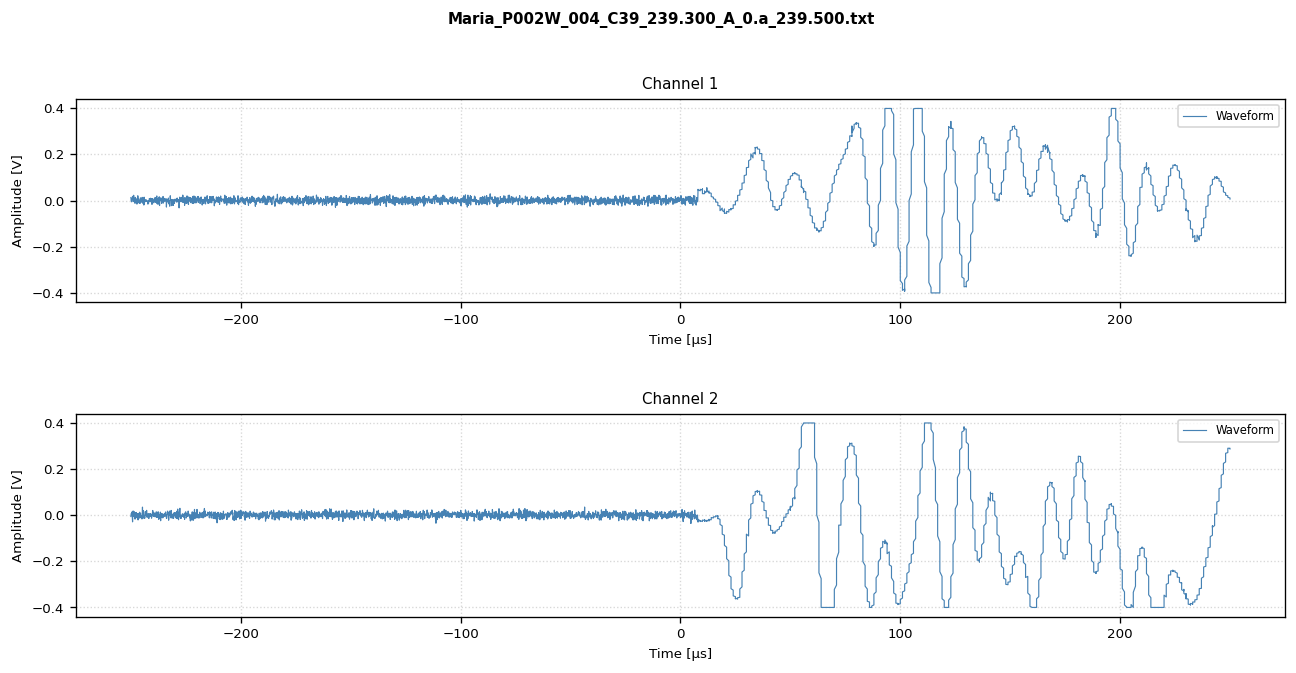

In [4]:
for idx in [0, len(all_data) // 2, -1]:
    fp, meta, channels = all_data[idx]
    fig = plot_channels(meta, channels, picks={}, signal_type="filtered")
    fig.suptitle(fp.name, fontsize=9, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## 3  Event picking — AIC, Refined STA/LTA

### 3a  Single-file demonstration

In [5]:
# ── PICKER PARAMETERS — edit these to tune both single-file and batch runs ──

# AIC: search window as fraction of record length (filtered signals, ±250 µs)
AIC_START_FRAC = 0.30   # search start  (0.40 → −50 µs)
AIC_END_FRAC   = 0.70   # search end    (0.60 → +50 µs)

# Refined STA/LTA
STA_S          = 5e-6   # short-term window  [seconds]
LTA_S          = 300e-6 # long-term window   [seconds]
STA_THRESH     = 3.5    # trigger-ON  ratio
LTA_THRESH     = 1.5    # trigger-OFF ratio
# Earliest allowed trigger as fraction of record length.
# 0.50 = t=0 (centre of ±250 µs window) — prevents pre-onset false triggers.
STALTA_SEARCH_START_FRAC = 0.50

print("Picker parameters:")
print(f"  AIC     search window    : {AIC_START_FRAC:.0%} – {AIC_END_FRAC:.0%} of record")
print(f"  STA/LTA STA={STA_S*1e6:.0f} µs  LTA={LTA_S*1e6:.0f} µs  "
      f"on={STA_THRESH}  off={LTA_THRESH}")
print(f"  STA/LTA earliest trigger : {STALTA_SEARCH_START_FRAC:.0%} of record (t=0)")

Picker parameters:
  AIC     search window    : 30% – 70% of record
  STA/LTA STA=5 µs  LTA=300 µs  on=3.5  off=1.5
  STA/LTA earliest trigger : 50% of record (t=0)


In [6]:
fp_demo, meta_demo, ch_demo = all_data[0]
N    = len(ch_demo[0]["time"])
n_ch = len(ch_demo)

aic_picks, rstalta_picks = [], []

for ch in ch_demo:
    amp, t = ch["amp"], ch["time"]

    idx_aic, _ = aic_picker(amp,
                            search_start=int(AIC_START_FRAC * N),
                            search_end=int(AIC_END_FRAC * N))
    aic_picks.append(idx_aic)

    idx_rs, _, _ = refined_stalta_picker(
        amp, t, sta_s=STA_S, lta_s=LTA_S,
        sta_thresh=STA_THRESH, lta_thresh=LTA_THRESH,
        search_start=int(STALTA_SEARCH_START_FRAC * N))
    rstalta_picks.append(idx_rs)

print(f"File: {fp_demo.name}")
print(f"Channels detected: {n_ch}\n")
print(f"  Ch    AIC (µs)   Refined STA/LTA (µs)")
for i, ch in enumerate(ch_demo):
    t = ch["time"]
    a = t[aic_picks[i]] * 1e6
    r = t[rstalta_picks[i]] * 1e6 if rstalta_picks[i] is not None else float("nan")
    print(f"  {i+1:2d}  {a:10.2f}  {r:21.2f}")

File: Maria_P002W_002_C66_261.930_A_0.a_262.160.txt
Channels detected: 2

  Ch    AIC (µs)   Refined STA/LTA (µs)
   1       10.00                  10.00
   2       16.00                  14.00


C:\Users\wamrieds\AppData\Local\Temp\ipykernel_34660\3676848933.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


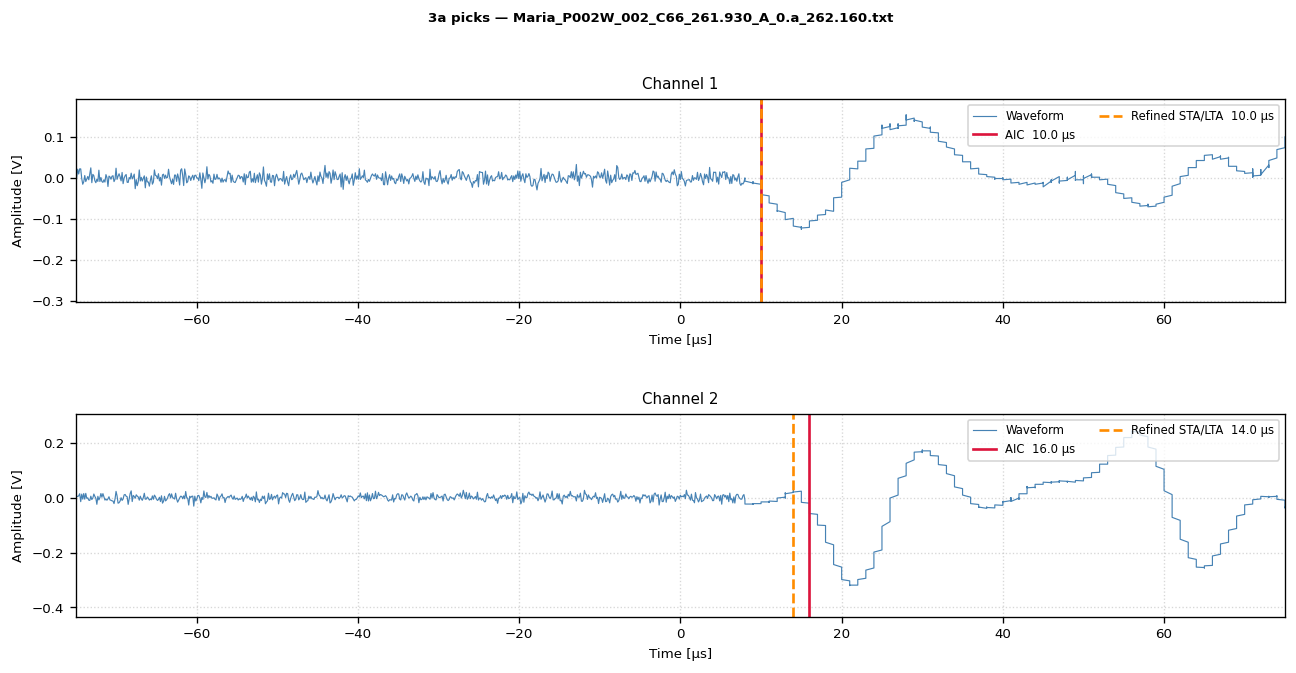

In [7]:
fig = plot_channels(
    meta_demo, ch_demo,
    picks={"AIC": aic_picks, "Refined STA/LTA": rstalta_picks},
    signal_type="filtered",
)
for ax in fig.get_axes():
    ax.set_xlim(-75, 75)
fig.suptitle(f"3a picks — {fp_demo.name}", fontsize=8, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3b  Batch run — all filtered files

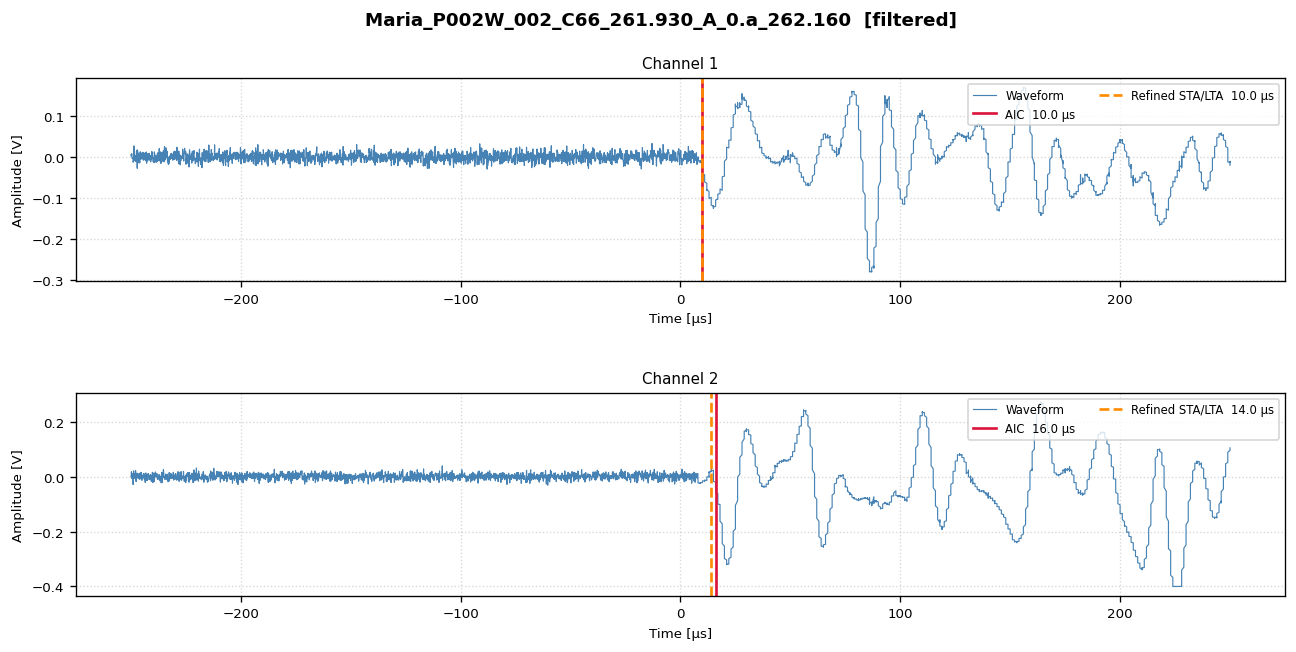

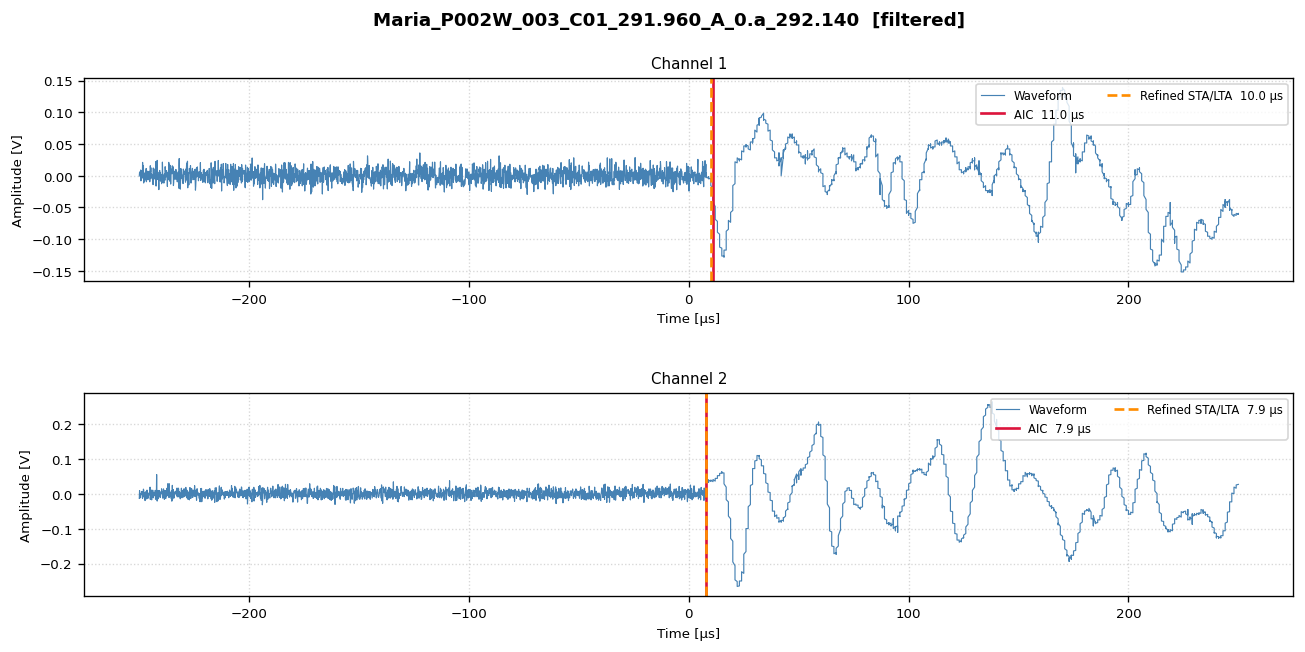

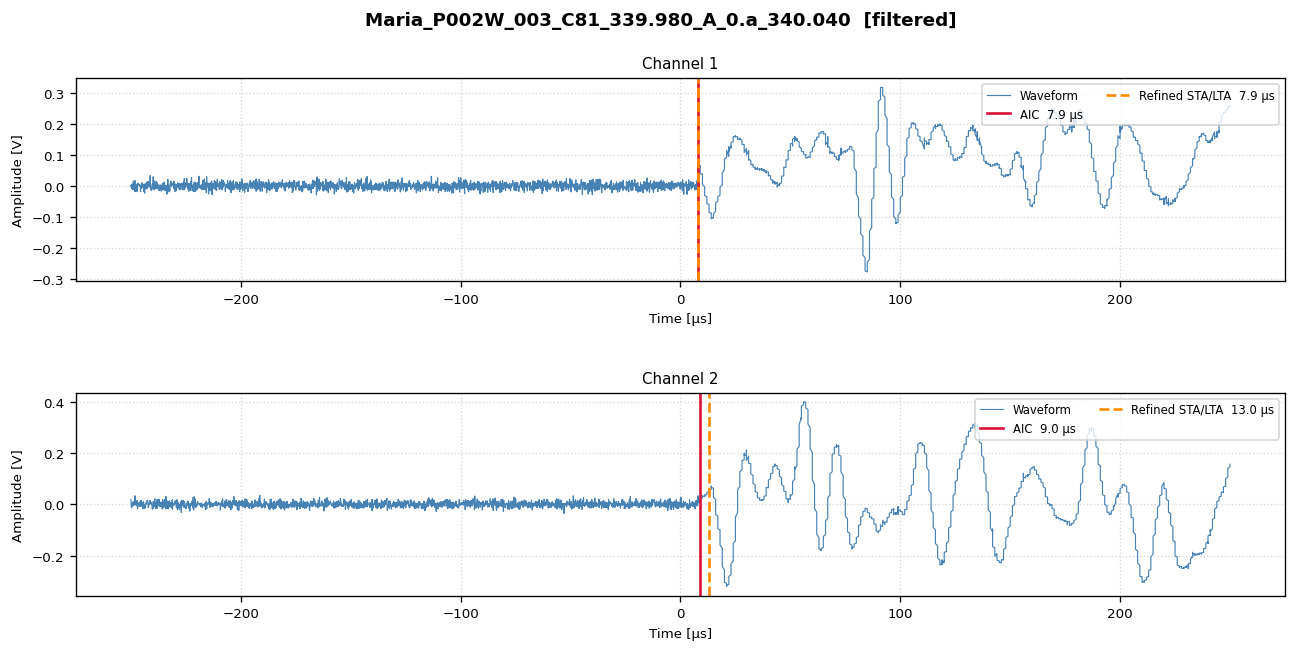

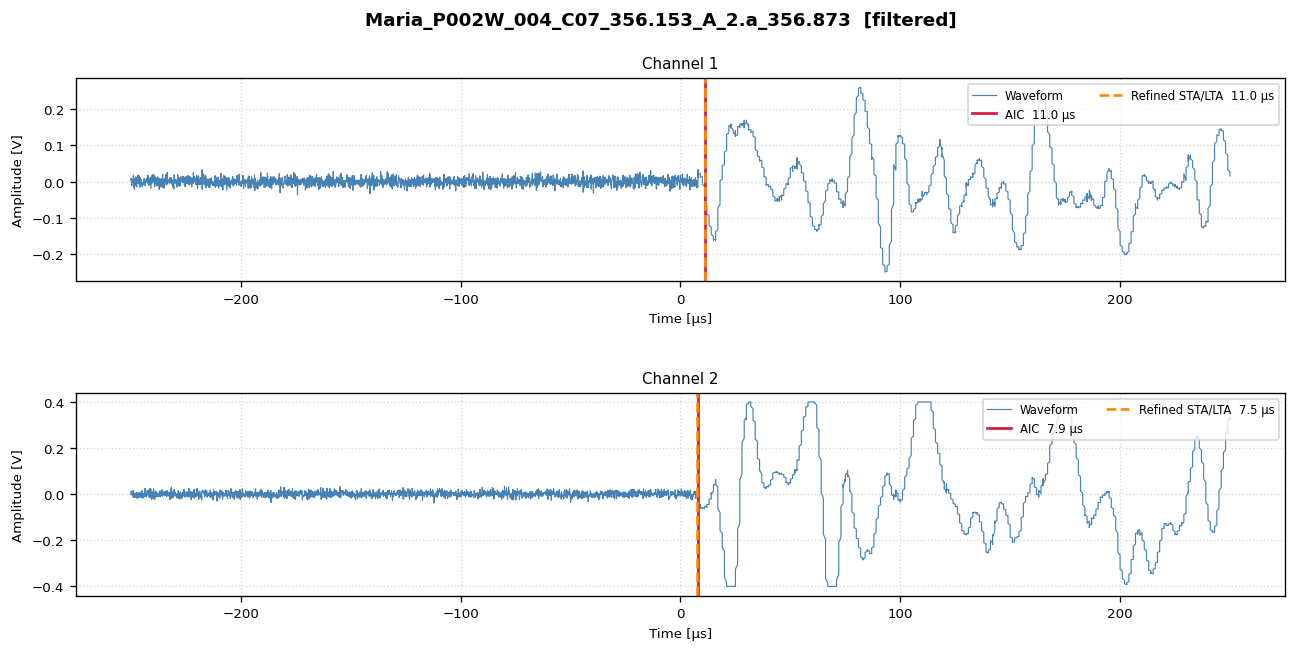

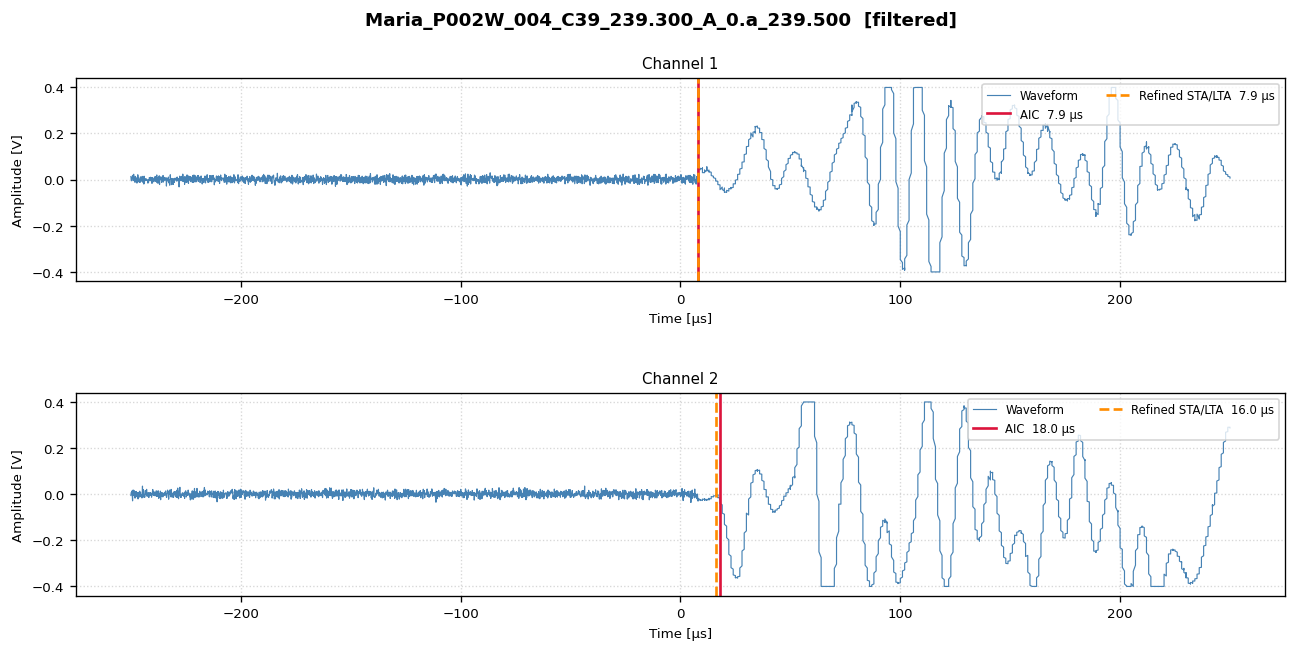

Total rows: 10


,file,signal_type,channel,aic_pick_us,refined_stalta_pick_us
0,Maria_P002W_002_C66_261.930_A_0.a_262.160.txt,filtered,1,10.00,10.00
1,Maria_P002W_002_C66_261.930_A_0.a_262.160.txt,filtered,2,16.00,14.00
2,Maria_P002W_003_C01_291.960_A_0.a_292.140.txt,filtered,1,11.00,10.00
3,Maria_P002W_003_C01_291.960_A_0.a_292.140.txt,filtered,2,7.87,7.87
4,Maria_P002W_003_C81_339.980_A_0.a_340.040.txt,filtered,1,7.87,7.87
5,Maria_P002W_003_C81_339.980_A_0.a_340.040.txt,filtered,2,9.00,13.00
6,Maria_P002W_004_C07_356.153_A_2.a_356.873.txt,filtered,1,11.00,11.00
7,Maria_P002W_004_C07_356.153_A_2.a_356.873.txt,filtered,2,7.87,7.50
8,Maria_P002W_004_C39_239.300_A_0.a_239.500.txt,filtered,1,7.87,7.87
9,Maria_P002W_004_C39_239.300_A_0.a_239.500.txt,filtered,2,18.00,16.00


In [13]:
all_results = []
for fp, _, _ in all_data:
    all_results.extend(pick_file(
        fp, signal_type="filtered",
        pickers=("aic", "refined_stalta"),
        aic_search_frac_filtered=(AIC_START_FRAC, AIC_END_FRAC),
        sta_s=STA_S, lta_s=LTA_S,
        refined_sta_thresh=STA_THRESH, refined_lta_thresh=LTA_THRESH,
        refined_search_start_frac=STALTA_SEARCH_START_FRAC,
        plot=True,
    ))

df = pd.DataFrame(all_results)
keep = ["file", "signal_type", "channel",
        "aic_pick_us", "refined_stalta_pick_us"]
df_picks = df[[c for c in keep if c in df.columns]].copy()
for col in ["aic_pick_us", "refined_stalta_pick_us"]:
    if col in df_picks.columns:
        df_picks[col] = df_picks[col].round(2)

print(f"Total rows: {len(df_picks)}")
display(df_picks)

In [9]:
csv_path = OUTPUT_DIR / "picks_summary_filtered.csv"
df_picks.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

Saved: ..\picks_output\picks_summary_filtered.csv


## 4  Compare the picks

No header reference exists for filtered signals.  
**Inter-picker spread** (max − min across all three methods per row) serves as a
quality proxy: smaller spread → higher inter-method agreement.

In [10]:
pick_cols = [c for c in ["aic_pick_us", "refined_stalta_pick_us"]
             if c in df_picks.columns]

df_picks["spread_us"] = df_picks[pick_cols].max(axis=1) - df_picks[pick_cols].min(axis=1)

print("Inter-picker spread by channel (mean ± std):")
print(
    df_picks.groupby("channel")["spread_us"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
    .to_string()
)

Inter-picker spread by channel (mean ± std):
         mean   std  min  max
channel                      
1        0.20  0.45  0.0  1.0
2        1.67  1.59  0.0  4.0


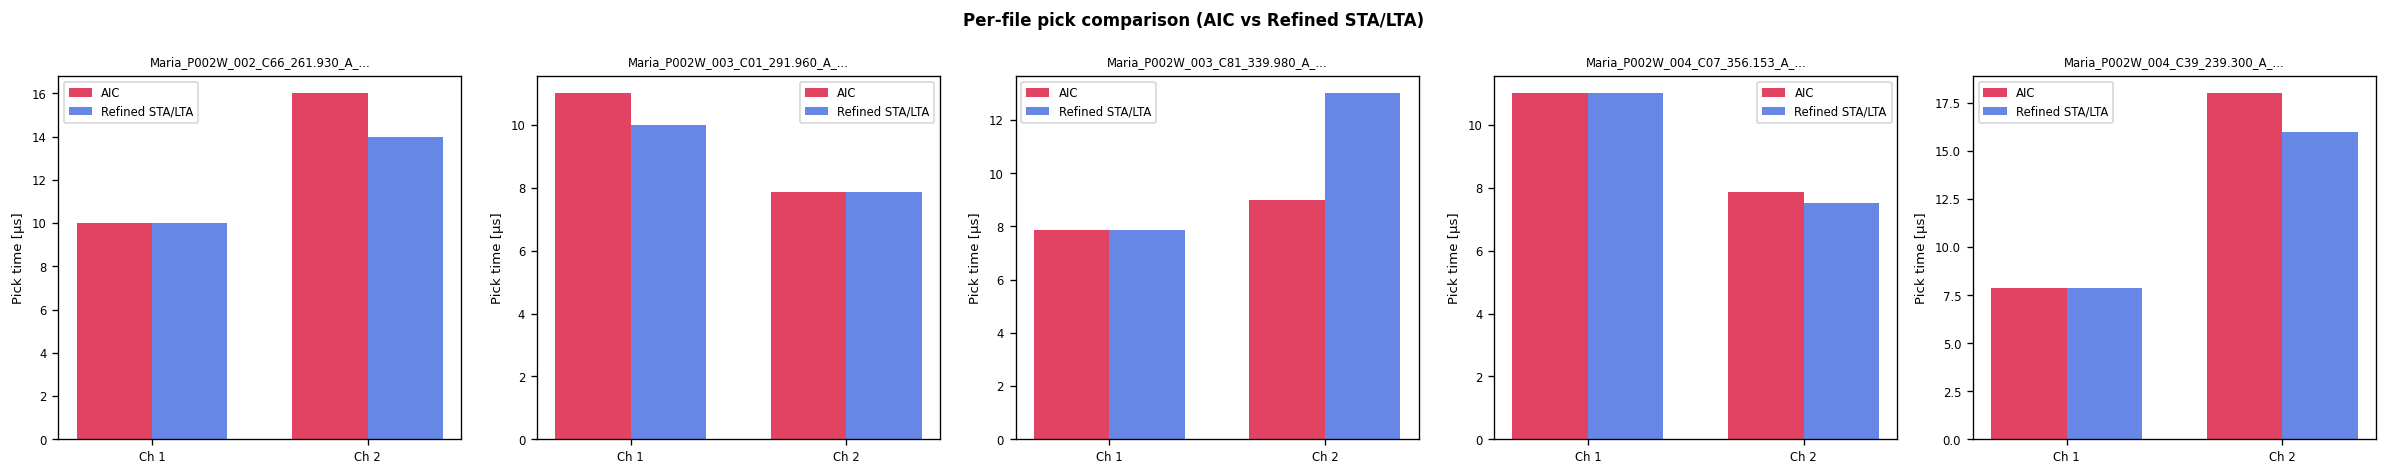

In [11]:
files_unique  = df_picks["file"].unique()
picker_labels = {"aic_pick_us": "AIC",
                 "refined_stalta_pick_us": "Refined STA/LTA"}
colors = ["crimson", "royalblue"]

fig, axes = plt.subplots(1, len(files_unique),
                         figsize=(4 * len(files_unique), 4), sharey=False)
if len(files_unique) == 1:
    axes = [axes]

for ax, fname in zip(axes, files_unique):
    sub = df_picks[df_picks["file"] == fname].sort_values("channel")
    x, w = np.arange(len(sub)), 0.35
    for j, (col, lbl) in enumerate(picker_labels.items()):
        if col in sub.columns:
            ax.bar(x + j * w, sub[col].values, w, label=lbl,
                   color=colors[j], alpha=0.8)
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels([f"Ch {c}" for c in sub["channel"].values])
    ax.set_ylabel("Pick time [µs]", fontsize=8)
    ax.set_title(fname[:30] + "...", fontsize=7)
    ax.axhline(0, color="k", lw=0.6, ls="--")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle("Per-file pick comparison (AIC vs Refined STA/LTA)", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pick_comparison_filtered.png", dpi=150, bbox_inches="tight")
plt.show()

## 5  Plot the picks

Both two pickers overlaid on each file; x-axis zoomed to ±75 µs around t = 0.

C:\Users\wamrieds\AppData\Local\Temp\ipykernel_34660\3092080011.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


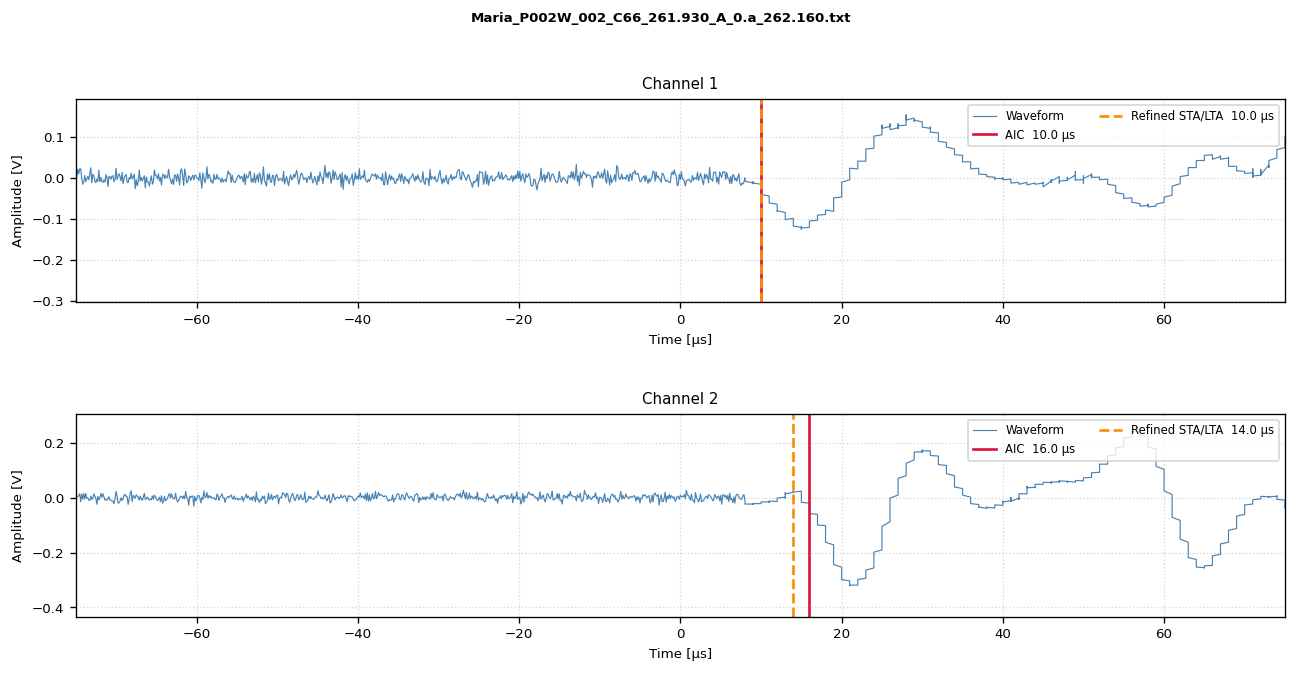

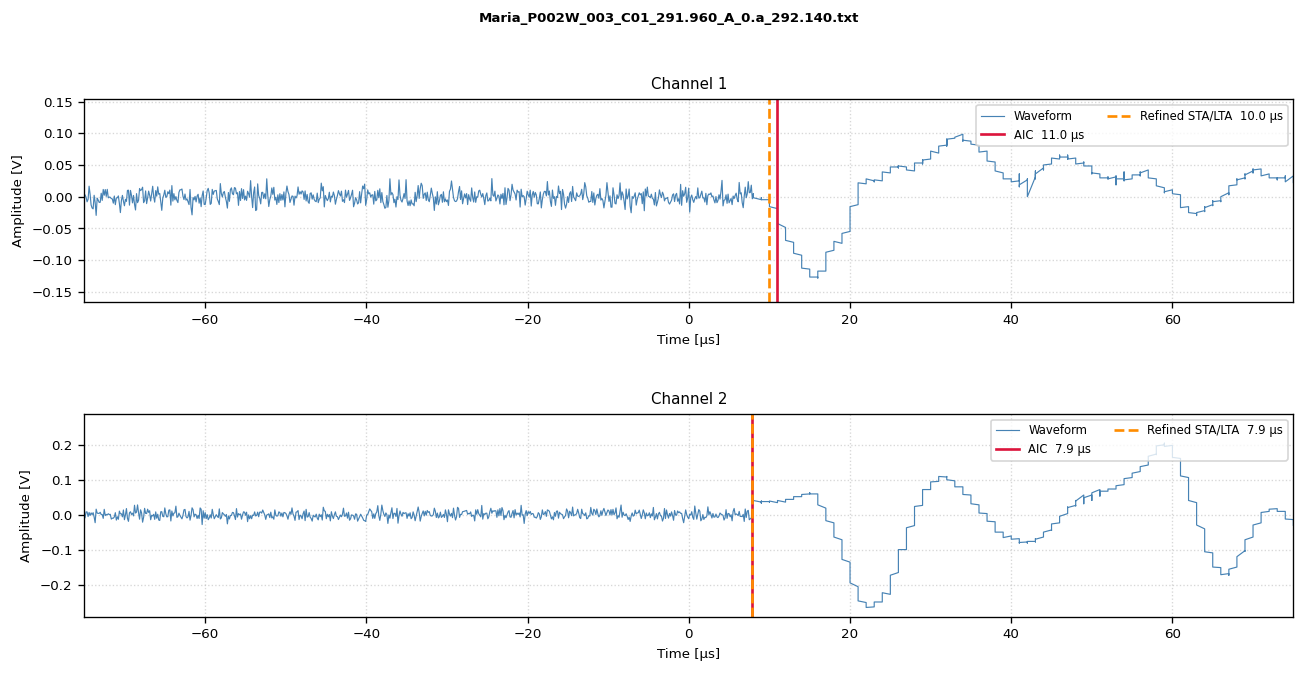

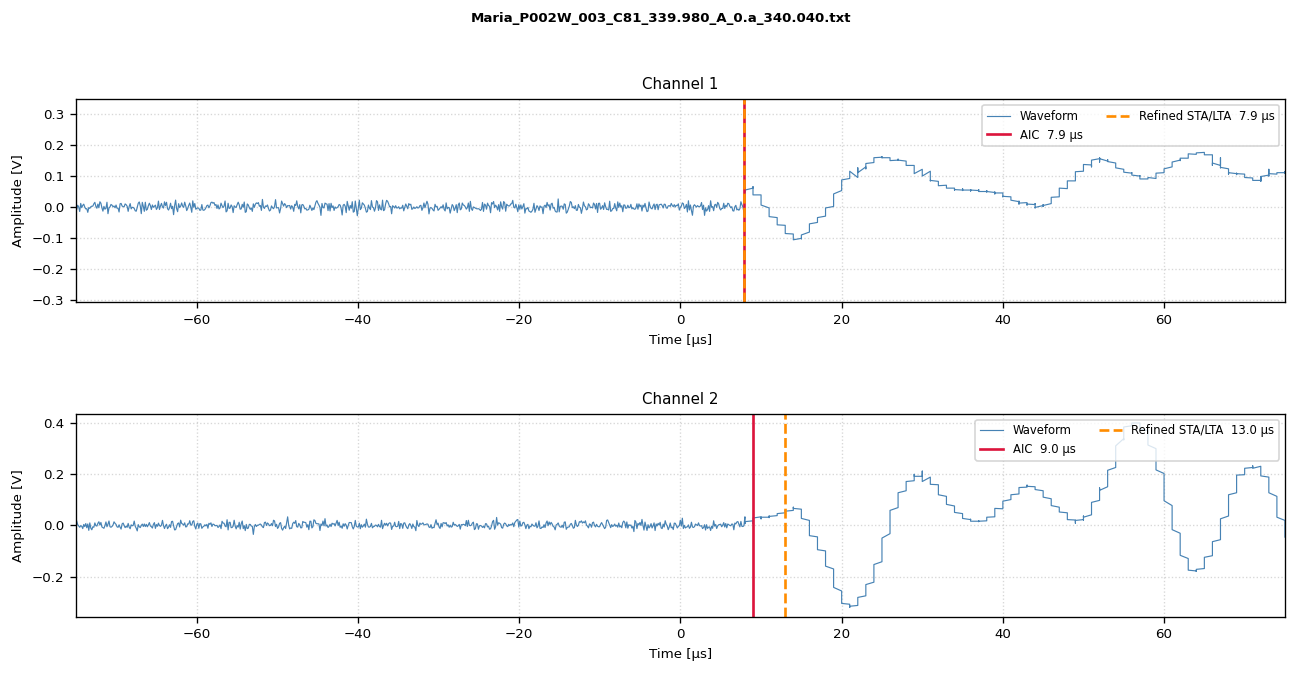

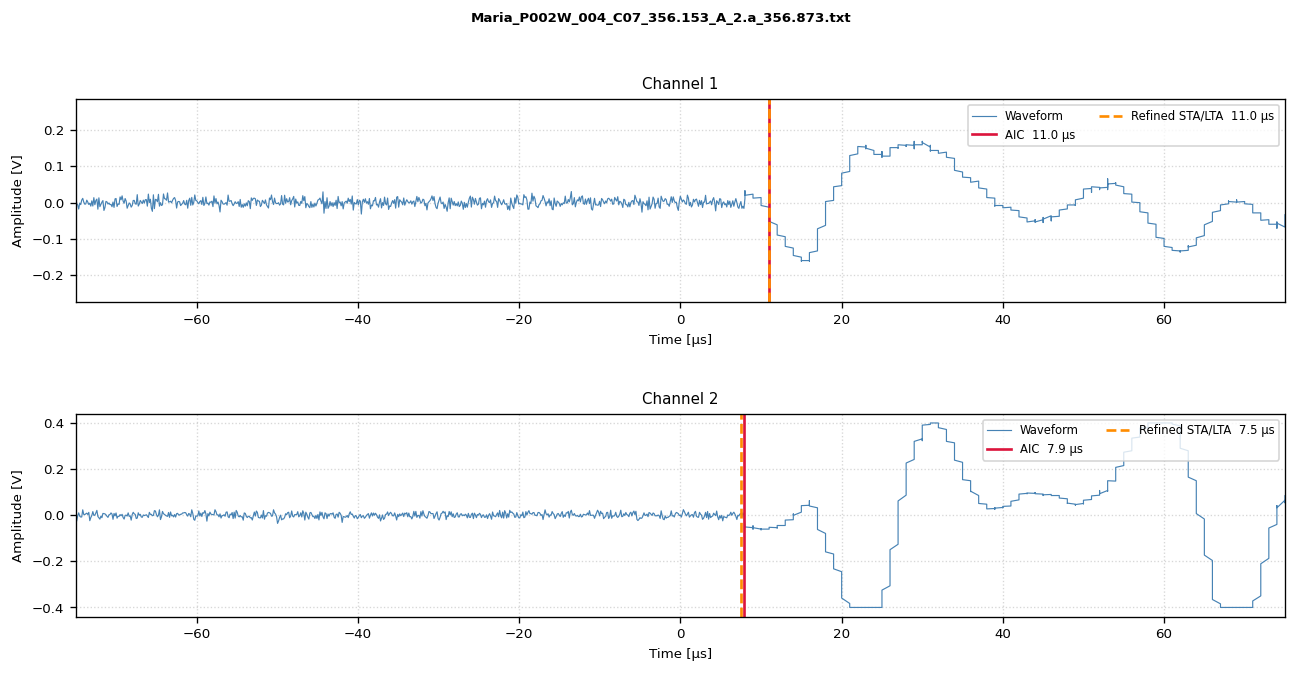

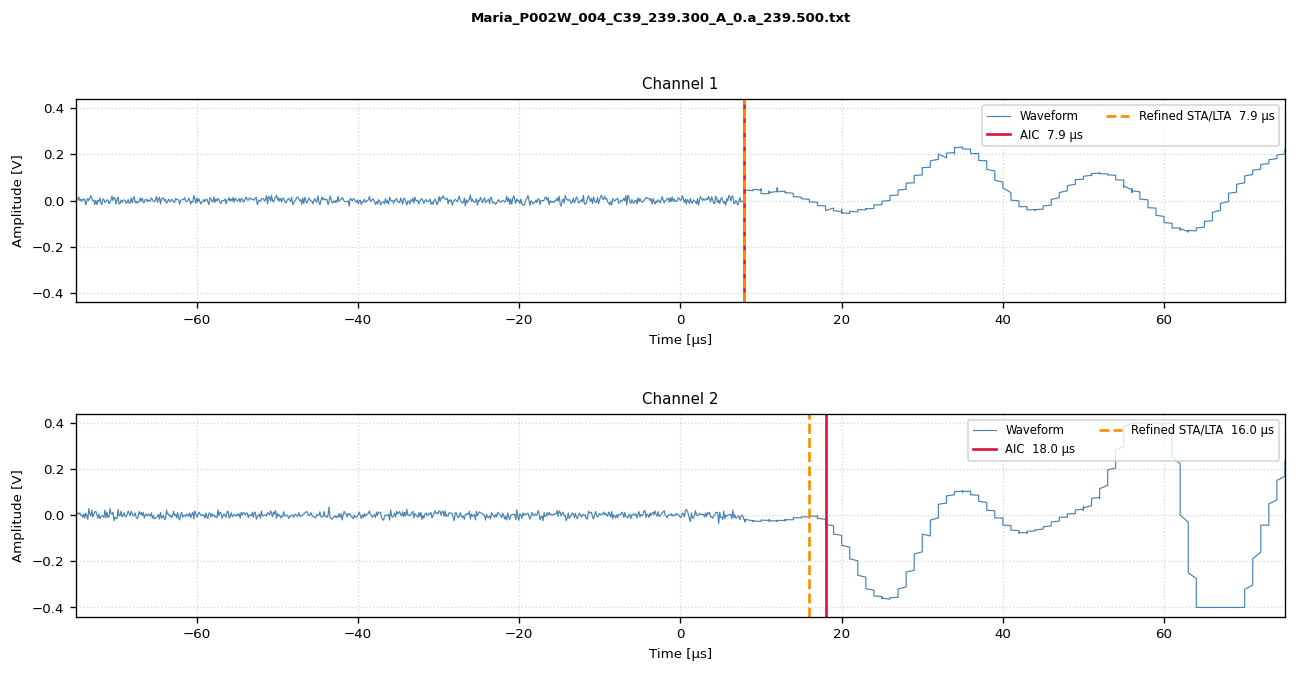

In [15]:
for fp, meta, channels in all_data:
    N_f = len(channels[0]["time"])
    aic_p, rs_p = [], []
    for ch in channels:
        amp, t = ch["amp"], ch["time"]
        idx_a, _ = aic_picker(amp,
                              search_start=int(AIC_START_FRAC * N_f),
                              search_end=int(AIC_END_FRAC * N_f))
        aic_p.append(idx_a)
        idx_r, _, _ = refined_stalta_picker(
            amp, t, sta_s=STA_S, lta_s=LTA_S, sta_thresh=STA_THRESH, lta_thresh=LTA_THRESH, search_start=int(STALTA_SEARCH_START_FRAC * N_f))
        rs_p.append(idx_r)

    fig = plot_channels(
        meta, channels,
        picks={"AIC": aic_p, "Refined STA/LTA": rs_p},
        signal_type="filtered",
        savepath=OUTPUT_DIR / (fp.stem + "_picks.png"),
    )
    for ax in fig.get_axes():
        ax.set_xlim(-75, 75)
    fig.suptitle(fp.name, fontsize=8, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## 6  Uncertainty quantification

Three complementary analyses without an external reference:
1. **Inter-picker spread** — box plot of max−min across both methods
2. **Threshold sensitivity** — Refined STA/LTA pick shift vs threshold
3. **AIC window sensitivity** — pick shift vs AIC search-start fraction

### 6a  Inter-picker spread (box plot)

C:\Users\wamrieds\AppData\Local\Temp\ipykernel_26648\1925985441.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxes, labels=[f"Ch {c}" for c in channels_unique],


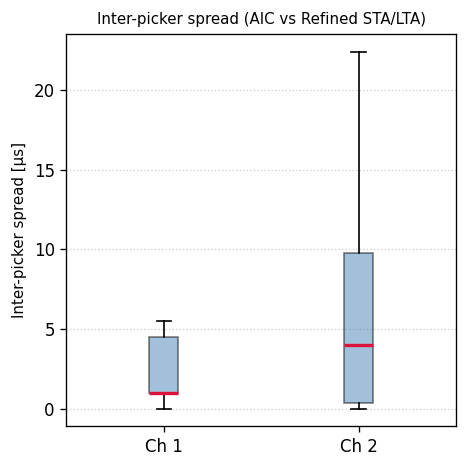

In [13]:
channels_unique = sorted(df_picks["channel"].unique())

fig, ax = plt.subplots(figsize=(max(4, len(channels_unique) * 1.5), 4))
boxes = [df_picks.loc[df_picks["channel"] == c, "spread_us"].dropna().values
         for c in channels_unique]
bp = ax.boxplot(boxes, labels=[f"Ch {c}" for c in channels_unique],
                patch_artist=True,
                medianprops={"color": "crimson", "lw": 2})
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.5)
ax.set_ylabel("Inter-picker spread [µs]", fontsize=9)
ax.set_title("Inter-picker spread (AIC vs Refined STA/LTA)", fontsize=9)
ax.grid(axis="y", ls=":", alpha=0.6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uq_interpicker_spread.png", dpi=150, bbox_inches="tight")
plt.show()

### 6b  Threshold sensitivity — Refined STA/LTA picker

C:\Users\wamrieds\AppData\Local\Temp\ipykernel_26648\3684024458.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(sweep_keys))


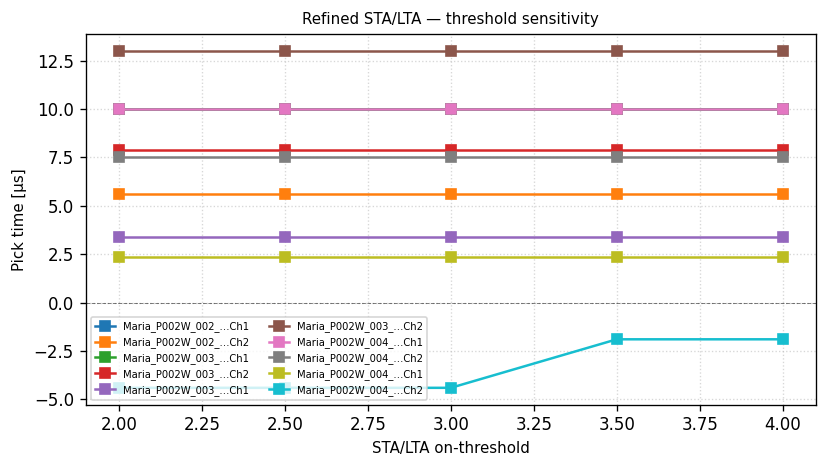

Refined STA/LTA pick std over threshold sweep:
  Ch 1: mean=7.15 µs  σ=3.51 µs
  Ch 2: mean=6.12 µs  σ=5.38 µs


In [14]:
thresholds = [2.0, 2.5, 3.0, 3.5, 4.0]
sweep_keys = [(fp.name, ci + 1) for fp, _, channels in all_data
              for ci in range(len(channels))]
cmap = plt.cm.get_cmap("tab10", len(sweep_keys))

rstalta_sweep = {}
for thr in thresholds:
    row = {}
    for fp, meta, channels in all_data:
        for ci, ch in enumerate(channels):
            amp, t = ch["amp"], ch["time"]
            idx, _, _ = refined_stalta_picker(
                amp, t, sta_s=2e-6, lta_s=100e-6,
                sta_thresh=thr, lta_thresh=max(1.0, thr - 1.0))
            row[(fp.name, ci + 1)] = t[idx] * 1e6 if idx is not None else float("nan")
    rstalta_sweep[thr] = row

fig, ax = plt.subplots(figsize=(7, 4))
for i, key in enumerate(sweep_keys):
    vals = [rstalta_sweep[thr].get(key, float("nan")) for thr in thresholds]
    ax.plot(thresholds, vals, marker="s", lw=1.5,
            label=f"{key[0][:16]}…Ch{key[1]}", color=cmap(i))
ax.set_xlabel("STA/LTA on-threshold", fontsize=9)
ax.set_ylabel("Pick time [µs]", fontsize=9)
ax.set_title("Refined STA/LTA — threshold sensitivity", fontsize=9)
ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.5)
ax.legend(fontsize=6, ncol=2)
ax.grid(ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uq_rstalta_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print("Refined STA/LTA pick std over threshold sweep:")
for ch_id in sorted({k[1] for k in sweep_keys}):
    vals = np.array([[rstalta_sweep[thr].get(k, float("nan")) for thr in thresholds]
                     for k in sweep_keys if k[1] == ch_id])
    print(f"  Ch {ch_id}: mean={np.nanmean(vals):.2f} µs  σ={np.nanstd(vals):.2f} µs")

### 6c  AIC window sensitivity

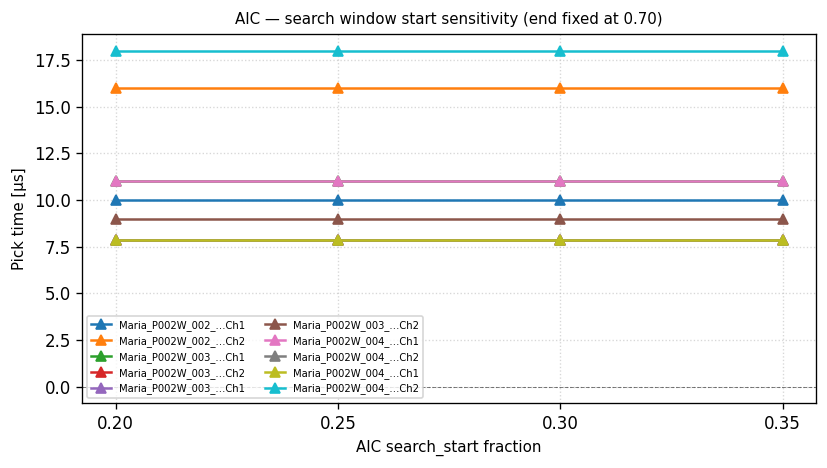

AIC pick std over window sweep:
  Ch 1: mean=9.55 µs  σ=1.42 µs
  Ch 2: mean=11.75 µs  σ=4.35 µs


In [15]:
start_fracs = [0.20, 0.25, 0.30, 0.35]
end_frac    = 0.70
aic_sweep   = {}

for sf in start_fracs:
    row = {}
    for fp, meta, channels in all_data:
        N_loc = len(channels[0]["time"])
        for ci, ch in enumerate(channels):
            amp, t = ch["amp"], ch["time"]
            idx, _ = aic_picker(amp,
                                search_start=int(sf * N_loc),
                                search_end=int(end_frac * N_loc))
            row[(fp.name, ci + 1)] = t[idx] * 1e6
    aic_sweep[sf] = row

fig, ax = plt.subplots(figsize=(7, 4))
for i, key in enumerate(sweep_keys):
    vals = [aic_sweep[sf][key] for sf in start_fracs]
    ax.plot([f"{sf:.2f}" for sf in start_fracs], vals, marker="^", lw=1.5,
            label=f"{key[0][:16]}…Ch{key[1]}", color=cmap(i))
ax.set_xlabel("AIC search_start fraction", fontsize=9)
ax.set_ylabel("Pick time [µs]", fontsize=9)
ax.set_title("AIC — search window start sensitivity (end fixed at 0.70)", fontsize=9)
ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.5)
ax.legend(fontsize=6, ncol=2)
ax.grid(ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uq_aic_window_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print("AIC pick std over window sweep:")
for ch_id in sorted({k[1] for k in sweep_keys}):
    vals = np.array([[aic_sweep[sf][k] for sf in start_fracs]
                     for k in sweep_keys if k[1] == ch_id])
    print(f"  Ch {ch_id}: mean={np.nanmean(vals):.2f} µs  σ={np.nanstd(vals):.2f} µs")

### 6d  Summary table

In [16]:
summary_rows = []
for ch_id in sorted(df_picks["channel"].unique()):
    sub = df_picks[df_picks["channel"] == ch_id]
    for col, label in [("aic_pick_us", "AIC"),
                       ("refined_stalta_pick_us", "Refined STA/LTA")]:
        if col in sub.columns:
            vals = sub[col].dropna()
            summary_rows.append({
                "channel":      ch_id,
                "method":       label,
                "mean_pick_us": round(vals.mean(), 2) if len(vals) else float("nan"),
                "std_us":       round(vals.std(),  2) if len(vals) > 1 else float("nan"),
                "n_valid":      len(vals),
            })

df_uq = pd.DataFrame(summary_rows)
print("Uncertainty summary (across all files):")
display(df_uq)

Uncertainty summary (across all files):


,channel,method,mean_pick_us,std_us,n_valid
0,1,AIC,9.55,1.59,5
1,1,Refined STA/LTA,7.15,3.92,5
2,2,AIC,11.75,4.87,5
3,2,Refined STA/LTA,6.04,6.38,5
